In [24]:
from pathlib import Path

# Define project root and data paths
PROJECT_ROOT = Path(r"C:\Users\wneis\Documents\GitHub\climate-risk-mockup")
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Create directories if they don't exist
DATA_INTERIM.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Print paths for verification
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_INTERIM:", DATA_INTERIM)
print("DATA_PROCESSED:", DATA_PROCESSED)


PROJECT_ROOT: C:\Users\wneis\Documents\GitHub\climate-risk-mockup
DATA_INTERIM: C:\Users\wneis\Documents\GitHub\climate-risk-mockup\data\interim
DATA_PROCESSED: C:\Users\wneis\Documents\GitHub\climate-risk-mockup\data\processed


In [2]:
import xarray as xr

# Example: Load a sample ERA5 dataset (replace with your actual data path)
# For now, we'll create a dummy dataset to test the workflow
temperature = xr.DataArray(
    data=[[280, 285], [282, 287]],  # Example temperature values in Kelvin
    dims=("lat", "lon"),
    coords={
        "lat": [40.0, 41.0],
        "lon": [-3.0, -4.0],
    },
    name="t2m",
)
ds = temperature.to_dataset()

# Convert Kelvin to Celsius
heat_index = ds["t2m"] - 273.15

# Save to interim
output_path = DATA_INTERIM / "era5_heat_sample.nc"
heat_index.to_netcdf(output_path)
print(f"Saved sample data to: {output_path}")


Saved sample data to: C:\Users\wneis\Documents\GitHub\climate-risk-mockup\data\interim\era5_heat_sample.nc


In [ ]:
import xarray as xr

# Load the sample data
data_path = DATA_INTERIM / "era5_heat_sample.nc"
ds = xr.open_dataset(data_path)

# Print dataset information including coordinates
print(ds)
print("Latitude:", ds.lat.values)
print("Longitude:", ds.lon.values)


<xarray.Dataset> Size: 64B
Dimensions:  (lat: 2, lon: 2)
Coordinates:
  * lat      (lat) float64 16B 40.0 41.0
  * lon      (lon) float64 16B -3.0 -4.0
Data variables:
    t2m      (lat, lon) float64 32B ...
Latitude: [40. 41.]
Longitude: [-3. -4.]


In [19]:
import rioxarray as rxr

# Rename latitude and longitude dimensions to 'y' and 'x'
ds = ds.rename({'lat': 'y', 'lon': 'x'})

# Set the CRS to WGS84
ds.rio.write_crs("epsg:4326", inplace=True)


<xarray.Dataset> Size: 72B
Dimensions:      (y: 2, x: 2)
Coordinates:
  * y            (y) float64 16B 40.0 41.0
  * x            (x) float64 16B -3.0 -4.0
    spatial_ref  int64 8B 0
Data variables:
    t2m          (y, x) float64 32B ...

In [20]:
# Save the data as a GeoTIFF
output_tif_path = DATA_INTERIM / "era5_heat_sample_corrected.tif"
ds.t2m.rio.to_raster(output_tif_path)
print(f"Saved GeoTIFF to: {output_tif_path}")


Saved GeoTIFF to: C:\Users\wneis\Documents\GitHub\climate-risk-mockup\data\interim\era5_heat_sample_corrected.tif


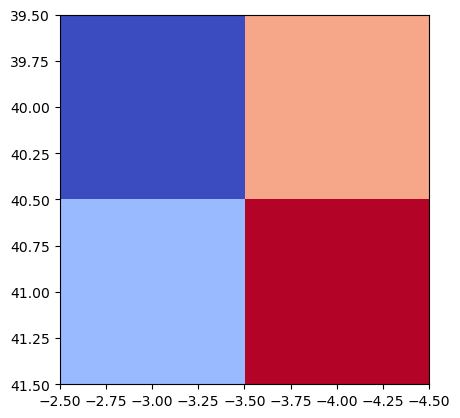

In [21]:
import rasterio
from rasterio.plot import show

# Open the GeoTIFF file and plot it to verify
with rasterio.open(output_tif_path) as src:
    show(src, cmap='coolwarm')


In [22]:
import folium
import numpy as np
from branca.colormap import LinearColormap

# Open the GeoTIFF file
with rasterio.open(output_tif_path) as src:
    img = src.read(1)
    bounds = src.bounds

# Create a base map
m = folium.Map(location=[40.0, -4.0], zoom_start=6)

# Define a colormap for temperature values
colormap = LinearColormap(
    colors=['blue', 'lightblue', 'lightgreen', 'yellow', 'orange', 'red'],
    vmin=np.nanmin(img),
    vmax=np.nanmax(img),
    caption='Temperature (°C)'
)

# Overlay the raster image on the map
folium.raster_layers.ImageOverlay(
    image=img,
    bounds=[[bounds.bottom, bounds.left], [bounds.top, bounds.right]],
    colormap=colormap,
).add_to(m)

# Add the colormap to the map
colormap.add_to(m)

# Save the map
map_path = PROJECT_ROOT / "maps" / "era5_heat_map_corrected.html"
m.save(map_path)
print(f"Map saved to: {map_path}")


Map saved to: C:\Users\wneis\Documents\GitHub\climate-risk-mockup\maps\era5_heat_map_corrected.html


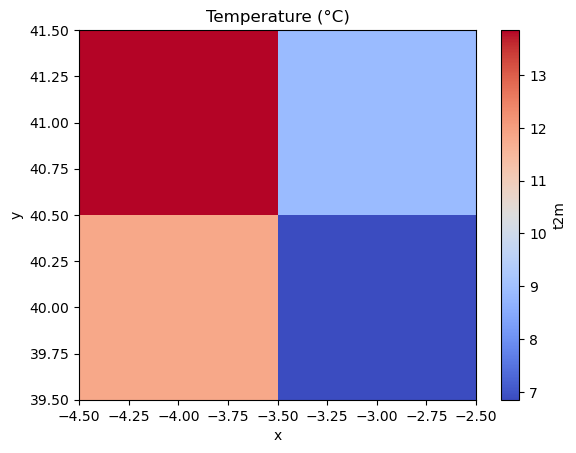

In [ ]:
import matplotlib.pyplot as plt

# Plot the temperature data
ds.t2m.plot(cmap='coolwarm')
plt.title("Temperature (°C)")
plt.show()


In [14]:
# Save the data as a GeoTIFF
output_tif_path = DATA_INTERIM / "era5_heat_sample.tif"
ds.t2m.rio.to_raster(output_tif_path)
print(f"Saved GeoTIFF to: {output_tif_path}")


Saved GeoTIFF to: C:\Users\wneis\Documents\GitHub\climate-risk-mockup\data\interim\era5_heat_sample.tif


In [15]:
import folium
import rasterio
import numpy as np
from rasterio.plot import reshape_as_image

# Open the GeoTIFF file
with rasterio.open(output_tif_path) as src:
    img = src.read(1)  # Read the first band
    bounds = src.bounds

# Create a base map
m = folium.Map(location=[40.0, -4.0], zoom_start=6)

# Overlay the raster image on the map
image_overlay = folium.raster_layers.ImageOverlay(
    image=img,
    bounds=[[bounds.bottom, bounds.left], [bounds.top, bounds.right]],
    colormap=lambda x: plt.cm.coolwarm(x / 255.0),  # Use a colormap
    interactive=True,
    cross_origin=False,
    zindex=1,
)
m.add_child(image_overlay)

# Save the map
map_path = PROJECT_ROOT / "maps" / "era5_heat_map.html"
m.save(map_path)
print(f"Map saved to: {map_path}")


Map saved to: C:\Users\wneis\Documents\GitHub\climate-risk-mockup\maps\era5_heat_map.html


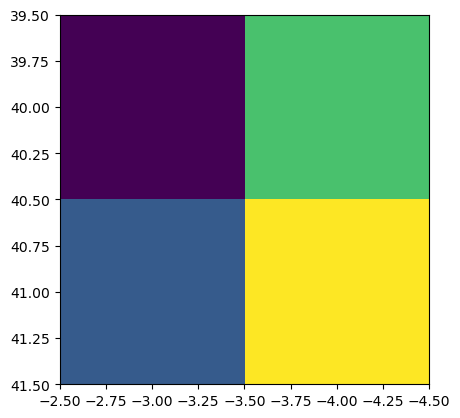

In [16]:
import rasterio
from rasterio.plot import show

# Open the GeoTIFF file and plot it to verify
with rasterio.open(DATA_INTERIM / "era5_heat_sample.tif") as src:
    show(src)


In [25]:
import cdsapi
from pathlib import Path

# Define paths
PROJECT_ROOT = Path(r"C:\Users\wneis\Documents\GitHub\climate-risk-mockup")
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"

# Define the request for the Iberian Peninsula
dataset = "derived-utci-historical"
request = {
    "variable": ["universal_thermal_climate_index"],
    "version": "1_1",
    "year": ["2020", "2021", "2022"],
    "month": ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"],
    "day": ["01", "15"],
    "area": [43.8, -9.5, 36.0, 3.5],  # North, West, South, East
    "format": "netcdf"
}

# Initialize the CDS API client
client = cdsapi.Client()

# Download the data
output_path = DATA_INTERIM / "utci_iberian_peninsula.nc"
client.retrieve(dataset, request, output_path)
print(f"Data downloaded to: {output_path}")


ModuleNotFoundError: No module named 'cdsapi'